In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as DataLoader
from torchvision import datasets, transforms

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [5]:
import os

# Define data directories
data_dir = os.path.join(path, "chest_xray")
train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")
val_dir = os.path.join(data_dir, "val")
print("Training data directory:", train_dir)
print("Testing data directory:", test_dir)
print("Validation data directory:", val_dir)

Training data directory: C:\Users\ASUS\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\train
Testing data directory: C:\Users\ASUS\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\test
Validation data directory: C:\Users\ASUS\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\val


In [6]:
# Define transformations for the training, validation, and testing sets
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

# Create data loaders
train_loader = DataLoader.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader.DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader.DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Number of training samples:", len(train_dataset))
print("Number of validation samples:", len(val_dataset))
print("Number of testing samples:", len(test_dataset))
print("Sum of all samples:", len(train_dataset) + len(val_dataset) + len(test_dataset))
print("Classes:", train_dataset.classes)

Number of training samples: 5216
Number of validation samples: 16
Number of testing samples: 624
Sum of all samples: 5856
Classes: ['NORMAL', 'PNEUMONIA']


In [7]:
# Check Size Images

dataiter = iter(train_loader)
images, labels = next(dataiter)
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 128, 128])
Label batch shape: torch.Size([32])


**CNN**

In [8]:
# CNN Model Definition
# 50 layers deep (matching ResNet50 depth without skip connections)
import torch
import torch.nn as nn

class CNN50(nn.Module):
    def __init__(self, num_classes=2):
        super(CNN50, self).__init__()
        
        # Initial conv layer (1 layer)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Layer 1: 3 bottleneck blocks (9 conv layers)
        # Block 1
        self.conv2_1a = nn.Conv2d(64, 64, kernel_size=1, stride=1, bias=False)
        self.bn2_1a = nn.BatchNorm2d(64)
        self.conv2_1b = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2_1b = nn.BatchNorm2d(64)
        self.conv2_1c = nn.Conv2d(64, 256, kernel_size=1, stride=1, bias=False)
        self.bn2_1c = nn.BatchNorm2d(256)
        self.conv2_1_expand = nn.Conv2d(64, 256, kernel_size=1, stride=1, bias=False)
        self.bn2_1_expand = nn.BatchNorm2d(256)
        
        # Block 2
        self.conv2_2a = nn.Conv2d(256, 64, kernel_size=1, stride=1, bias=False)
        self.bn2_2a = nn.BatchNorm2d(64)
        self.conv2_2b = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2_2b = nn.BatchNorm2d(64)
        self.conv2_2c = nn.Conv2d(64, 256, kernel_size=1, stride=1, bias=False)
        self.bn2_2c = nn.BatchNorm2d(256)
        
        # Block 3
        self.conv2_3a = nn.Conv2d(256, 64, kernel_size=1, stride=1, bias=False)
        self.bn2_3a = nn.BatchNorm2d(64)
        self.conv2_3b = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2_3b = nn.BatchNorm2d(64)
        self.conv2_3c = nn.Conv2d(64, 256, kernel_size=1, stride=1, bias=False)
        self.bn2_3c = nn.BatchNorm2d(256)
        
        # Layer 2: 4 bottleneck blocks (12 conv layers)
        # Block 1 (with stride=2)
        self.conv3_1a = nn.Conv2d(256, 128, kernel_size=1, stride=1, bias=False)
        self.bn3_1a = nn.BatchNorm2d(128)
        self.conv3_1b = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn3_1b = nn.BatchNorm2d(128)
        self.conv3_1c = nn.Conv2d(128, 512, kernel_size=1, stride=1, bias=False)
        self.bn3_1c = nn.BatchNorm2d(512)
        self.conv3_1_down = nn.Conv2d(256, 512, kernel_size=1, stride=2, bias=False)
        self.bn3_1_down = nn.BatchNorm2d(512)
        
        # Block 2
        self.conv3_2a = nn.Conv2d(512, 128, kernel_size=1, stride=1, bias=False)
        self.bn3_2a = nn.BatchNorm2d(128)
        self.conv3_2b = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn3_2b = nn.BatchNorm2d(128)
        self.conv3_2c = nn.Conv2d(128, 512, kernel_size=1, stride=1, bias=False)
        self.bn3_2c = nn.BatchNorm2d(512)
        
        # Block 3
        self.conv3_3a = nn.Conv2d(512, 128, kernel_size=1, stride=1, bias=False)
        self.bn3_3a = nn.BatchNorm2d(128)
        self.conv3_3b = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn3_3b = nn.BatchNorm2d(128)
        self.conv3_3c = nn.Conv2d(128, 512, kernel_size=1, stride=1, bias=False)
        self.bn3_3c = nn.BatchNorm2d(512)
        
        # Block 4
        self.conv3_4a = nn.Conv2d(512, 128, kernel_size=1, stride=1, bias=False)
        self.bn3_4a = nn.BatchNorm2d(128)
        self.conv3_4b = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn3_4b = nn.BatchNorm2d(128)
        self.conv3_4c = nn.Conv2d(128, 512, kernel_size=1, stride=1, bias=False)
        self.bn3_4c = nn.BatchNorm2d(512)
        
        # Layer 3: 6 bottleneck blocks (18 conv layers)
        # Block 1 (with stride=2)
        self.conv4_1a = nn.Conv2d(512, 256, kernel_size=1, stride=1, bias=False)
        self.bn4_1a = nn.BatchNorm2d(256)
        self.conv4_1b = nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn4_1b = nn.BatchNorm2d(256)
        self.conv4_1c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
        self.bn4_1c = nn.BatchNorm2d(1024)
        self.conv4_1_down = nn.Conv2d(512, 1024, kernel_size=1, stride=2, bias=False)
        self.bn4_1_down = nn.BatchNorm2d(1024)
        
        # Block 2
        self.conv4_2a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
        self.bn4_2a = nn.BatchNorm2d(256)
        self.conv4_2b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn4_2b = nn.BatchNorm2d(256)
        self.conv4_2c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
        self.bn4_2c = nn.BatchNorm2d(1024)
        
        # Block 3
        self.conv4_3a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
        self.bn4_3a = nn.BatchNorm2d(256)
        self.conv4_3b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn4_3b = nn.BatchNorm2d(256)
        self.conv4_3c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
        self.bn4_3c = nn.BatchNorm2d(1024)
        
        # Block 4
        self.conv4_4a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
        self.bn4_4a = nn.BatchNorm2d(256)
        self.conv4_4b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn4_4b = nn.BatchNorm2d(256)
        self.conv4_4c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
        self.bn4_4c = nn.BatchNorm2d(1024)
        
        # Block 5
        self.conv4_5a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
        self.bn4_5a = nn.BatchNorm2d(256)
        self.conv4_5b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn4_5b = nn.BatchNorm2d(256)
        self.conv4_5c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
        self.bn4_5c = nn.BatchNorm2d(1024)
        
        # Block 6
        self.conv4_6a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
        self.bn4_6a = nn.BatchNorm2d(256)
        self.conv4_6b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn4_6b = nn.BatchNorm2d(256)
        self.conv4_6c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
        self.bn4_6c = nn.BatchNorm2d(1024)
        
        # Layer 4: 3 bottleneck blocks (9 conv layers)
        # Block 1 (with stride=2)
        self.conv5_1a = nn.Conv2d(1024, 512, kernel_size=1, stride=1, bias=False)
        self.bn5_1a = nn.BatchNorm2d(512)
        self.conv5_1b = nn.Conv2d(512, 512, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn5_1b = nn.BatchNorm2d(512)
        self.conv5_1c = nn.Conv2d(512, 2048, kernel_size=1, stride=1, bias=False)
        self.bn5_1c = nn.BatchNorm2d(2048)
        self.conv5_1_down = nn.Conv2d(1024, 2048, kernel_size=1, stride=2, bias=False)
        self.bn5_1_down = nn.BatchNorm2d(2048)
        
        # Block 2
        self.conv5_2a = nn.Conv2d(2048, 512, kernel_size=1, stride=1, bias=False)
        self.bn5_2a = nn.BatchNorm2d(512)
        self.conv5_2b = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn5_2b = nn.BatchNorm2d(512)
        self.conv5_2c = nn.Conv2d(512, 2048, kernel_size=1, stride=1, bias=False)
        self.bn5_2c = nn.BatchNorm2d(2048)
        
        # Block 3
        self.conv5_3a = nn.Conv2d(2048, 512, kernel_size=1, stride=1, bias=False)
        self.bn5_3a = nn.BatchNorm2d(512)
        self.conv5_3b = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn5_3b = nn.BatchNorm2d(512)
        self.conv5_3c = nn.Conv2d(512, 2048, kernel_size=1, stride=1, bias=False)
        self.bn5_3c = nn.BatchNorm2d(2048)
        
        # Total: 1 + 9 + 12 + 18 + 9 = 49 conv layers + 1 fc = 50 layers
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(2048, num_classes)
        
        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # Initial layers
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        # Layer 1 - Block 1 (with expansion)
        identity = self.conv2_1_expand(x)
        identity = self.bn2_1_expand(identity)
        x = self.relu(self.bn2_1a(self.conv2_1a(x)))
        x = self.relu(self.bn2_1b(self.conv2_1b(x)))
        x = self.bn2_1c(self.conv2_1c(x))
        x = self.relu(x + identity)
        
        # Layer 1 - Block 2
        identity = x
        x = self.relu(self.bn2_2a(self.conv2_2a(x)))
        x = self.relu(self.bn2_2b(self.conv2_2b(x)))
        x = self.bn2_2c(self.conv2_2c(x))
        x = self.relu(x + identity)
        
        # Layer 1 - Block 3
        identity = x
        x = self.relu(self.bn2_3a(self.conv2_3a(x)))
        x = self.relu(self.bn2_3b(self.conv2_3b(x)))
        x = self.bn2_3c(self.conv2_3c(x))
        x = self.relu(x + identity)
        
        # Layer 2 - Block 1 (with downsample)
        identity = self.bn3_1_down(self.conv3_1_down(x))
        x = self.relu(self.bn3_1a(self.conv3_1a(x)))
        x = self.relu(self.bn3_1b(self.conv3_1b(x)))
        x = self.bn3_1c(self.conv3_1c(x))
        x = self.relu(x + identity)
        
        # Layer 2 - Block 2
        identity = x
        x = self.relu(self.bn3_2a(self.conv3_2a(x)))
        x = self.relu(self.bn3_2b(self.conv3_2b(x)))
        x = self.bn3_2c(self.conv3_2c(x))
        x = self.relu(x + identity)
        
        # Layer 2 - Block 3
        identity = x
        x = self.relu(self.bn3_3a(self.conv3_3a(x)))
        x = self.relu(self.bn3_3b(self.conv3_3b(x)))
        x = self.bn3_3c(self.conv3_3c(x))
        x = self.relu(x + identity)
        
        # Layer 2 - Block 4
        identity = x
        x = self.relu(self.bn3_4a(self.conv3_4a(x)))
        x = self.relu(self.bn3_4b(self.conv3_4b(x)))
        x = self.bn3_4c(self.conv3_4c(x))
        x = self.relu(x + identity)
        
        # Layer 3 - Block 1 (with downsample)
        identity = self.bn4_1_down(self.conv4_1_down(x))
        x = self.relu(self.bn4_1a(self.conv4_1a(x)))
        x = self.relu(self.bn4_1b(self.conv4_1b(x)))
        x = self.bn4_1c(self.conv4_1c(x))
        x = self.relu(x + identity)
        
        # Layer 3 - Block 2
        identity = x
        x = self.relu(self.bn4_2a(self.conv4_2a(x)))
        x = self.relu(self.bn4_2b(self.conv4_2b(x)))
        x = self.bn4_2c(self.conv4_2c(x))
        x = self.relu(x + identity)
        
        # Layer 3 - Block 3
        identity = x
        x = self.relu(self.bn4_3a(self.conv4_3a(x)))
        x = self.relu(self.bn4_3b(self.conv4_3b(x)))
        x = self.bn4_3c(self.conv4_3c(x))
        x = self.relu(x + identity)
        
        # Layer 3 - Block 4
        identity = x
        x = self.relu(self.bn4_4a(self.conv4_4a(x)))
        x = self.relu(self.bn4_4b(self.conv4_4b(x)))
        x = self.bn4_4c(self.conv4_4c(x))
        x = self.relu(x + identity)
        
        # Layer 3 - Block 5
        identity = x
        x = self.relu(self.bn4_5a(self.conv4_5a(x)))
        x = self.relu(self.bn4_5b(self.conv4_5b(x)))
        x = self.bn4_5c(self.conv4_5c(x))
        x = self.relu(x + identity)
        
        # Layer 3 - Block 6
        identity = x
        x = self.relu(self.bn4_6a(self.conv4_6a(x)))
        x = self.relu(self.bn4_6b(self.conv4_6b(x)))
        x = self.bn4_6c(self.conv4_6c(x))
        x = self.relu(x + identity)
        
        # Layer 4 - Block 1 (with downsample)
        identity = self.bn5_1_down(self.conv5_1_down(x))
        x = self.relu(self.bn5_1a(self.conv5_1a(x)))
        x = self.relu(self.bn5_1b(self.conv5_1b(x)))
        x = self.bn5_1c(self.conv5_1c(x))
        x = self.relu(x + identity)
        
        # Layer 4 - Block 2
        identity = x
        x = self.relu(self.bn5_2a(self.conv5_2a(x)))
        x = self.relu(self.bn5_2b(self.conv5_2b(x)))
        x = self.bn5_2c(self.conv5_2c(x))
        x = self.relu(x + identity)
        
        # Layer 4 - Block 3
        identity = x
        x = self.relu(self.bn5_3a(self.conv5_3a(x)))
        x = self.relu(self.bn5_3b(self.conv5_3b(x)))
        x = self.bn5_3c(self.conv5_3c(x))
        x = self.relu(x + identity)
        
        # Final layers
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x


model = CNN50(num_classes=2).to(device)
print(model)

CNN50(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (conv2_1a): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn2_1a): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_1b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2_1b): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_1c): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn2_1c): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_1_expand): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn2_1_expand): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

In [9]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 23,512,130
Trainable parameters: 23,512,130


In [10]:
test_input = torch.randn(1, 3, 128, 128).to(device)
test_output = model(test_input)
print(f"\nTest input shape: {test_input.shape}")
print(f"Test output shape: {test_output.shape}")


Test input shape: torch.Size([1, 3, 128, 128])
Test output shape: torch.Size([1, 2])


In [11]:
# Training Setup

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

**Train - CNN**

In [12]:
# Train with Validation

epochs = 7

best_val_loss = float('inf')
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_acc = 100 * train_correct / train_total
    train_loss_list.append(epoch_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_epoch_loss = val_loss / len(val_loader.dataset)
    val_acc = 100 * val_correct / val_total
    val_loss_list.append(val_epoch_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"  Train Loss: {epoch_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print("-" * 50)
    
    # Save best model
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), 'best_cnn_model.pth')
        print(f"Best model saved! (Val Loss: {val_epoch_loss:.4f})")
        print("-" * 50)

print(f"\nTraining completed! Best Validation Loss: {best_val_loss:.4f}")

Epoch [1/7]
  Train Loss: 0.2693, Train Acc: 90.36%
  Val Loss: 1.7013, Val Acc: 62.50%
--------------------------------------------------
Best model saved! (Val Loss: 1.7013)
--------------------------------------------------
Epoch [2/7]
  Train Loss: 0.1311, Train Acc: 95.17%
  Val Loss: 0.1509, Val Acc: 93.75%
--------------------------------------------------
Best model saved! (Val Loss: 0.1509)
--------------------------------------------------
Epoch [3/7]
  Train Loss: 0.0891, Train Acc: 96.51%
  Val Loss: 1.8086, Val Acc: 68.75%
--------------------------------------------------
Epoch [4/7]
  Train Loss: 0.0891, Train Acc: 96.68%
  Val Loss: 0.5371, Val Acc: 81.25%
--------------------------------------------------
Epoch [5/7]
  Train Loss: 0.0699, Train Acc: 97.26%
  Val Loss: 0.5155, Val Acc: 75.00%
--------------------------------------------------
Epoch [6/7]
  Train Loss: 0.0583, Train Acc: 97.81%
  Val Loss: 1.0977, Val Acc: 68.75%
-----------------------------------------

**Result - CNN**

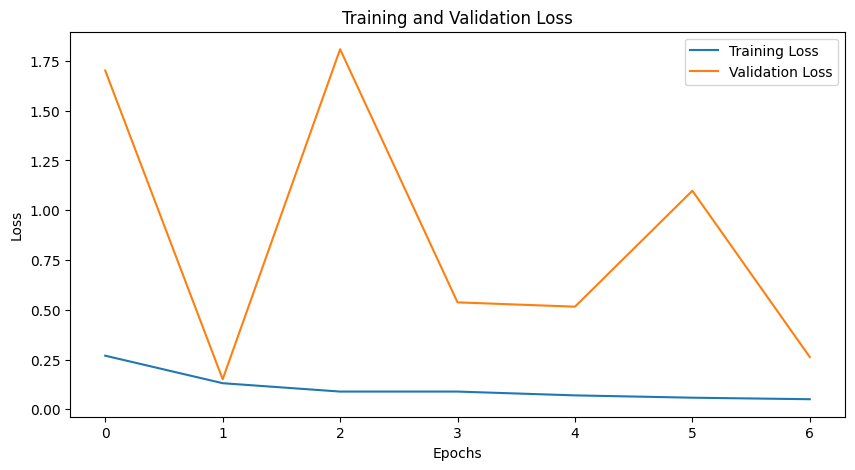

In [13]:
# Plot Training and Validation Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

--------------------------------------------------
FINAL TEST RESULTS
--------------------------------------------------
Test Accuracy: 80.61%

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.90      0.54      0.68       234
   PNEUMONIA       0.78      0.96      0.86       390

    accuracy                           0.81       624
   macro avg       0.84      0.75      0.77       624
weighted avg       0.82      0.81      0.79       624

Confusion Matrix:


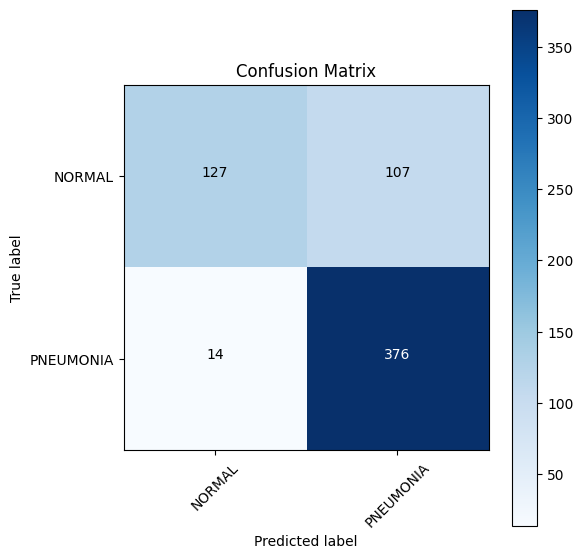


True Negatives (NORMAL correctly predicted): 127
False Positives (NORMAL predicted as PNEUMONIA): 107
False Negatives (PNEUMONIA predicted as NORMAL): 14
True Positives (PNEUMONIA correctly predicted): 376


In [14]:
# Test Results
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best model
model.load_state_dict(torch.load('best_cnn_model.pth'))
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate metrics
test_acc = 100 * np.sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)

print("-" * 50)
print(f"FINAL TEST RESULTS")
print("-" * 50)
print(f"Test Accuracy: {test_acc:.2f}%\n")

# Classification Report
class_names = ['NORMAL', 'PNEUMONIA']
print("Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=class_names))

# Confusion Matrix
print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (NORMAL correctly predicted): {cm[0][0]}")
print(f"False Positives (NORMAL predicted as PNEUMONIA): {cm[0][1]}")
print(f"False Negatives (PNEUMONIA predicted as NORMAL): {cm[1][0]}")
print(f"True Positives (PNEUMONIA correctly predicted): {cm[1][1]}")

**ResNet50**

ResNet50 with residual connections (skip connections) - Architecture follows the original ResNet paper

In [ ]:
# ResNet50 Manual Implementation (Bottleneck Blocks - Commented Out)
# import torch
# import torch.nn as nn

# class ResNet50Manual(nn.Module):
#     def __init__(self, num_classes=2):
#         super(ResNet50Manual, self).__init__()
        
#         # Initial conv layer
#         self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
#         self.bn1 = nn.BatchNorm2d(64)
#         self.relu = nn.ReLU(inplace=True)
#         self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
#         # Layer 1: 3 bottleneck blocks (9 conv layers)
#         # Block 1 (with expansion 64->256)
#         self.conv2_1a = nn.Conv2d(64, 64, kernel_size=1, stride=1, bias=False)
#         self.bn2_1a = nn.BatchNorm2d(64)
#         self.conv2_1b = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn2_1b = nn.BatchNorm2d(64)
#         self.conv2_1c = nn.Conv2d(64, 256, kernel_size=1, stride=1, bias=False)
#         self.bn2_1c = nn.BatchNorm2d(256)
#         self.downsample2_1 = nn.Sequential(
#             nn.Conv2d(64, 256, kernel_size=1, stride=1, bias=False),
#             nn.BatchNorm2d(256)
#         )
        
#         # Block 2
#         self.conv2_2a = nn.Conv2d(256, 64, kernel_size=1, stride=1, bias=False)
#         self.bn2_2a = nn.BatchNorm2d(64)
#         self.conv2_2b = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn2_2b = nn.BatchNorm2d(64)
#         self.conv2_2c = nn.Conv2d(64, 256, kernel_size=1, stride=1, bias=False)
#         self.bn2_2c = nn.BatchNorm2d(256)
        
#         # Block 3
#         self.conv2_3a = nn.Conv2d(256, 64, kernel_size=1, stride=1, bias=False)
#         self.bn2_3a = nn.BatchNorm2d(64)
#         self.conv2_3b = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn2_3b = nn.BatchNorm2d(64)
#         self.conv2_3c = nn.Conv2d(64, 256, kernel_size=1, stride=1, bias=False)
#         self.bn2_3c = nn.BatchNorm2d(256)
        
#         # Layer 2: 4 bottleneck blocks (12 conv layers)
#         # Block 1 (with stride=2, expansion 256->512)
#         self.conv3_1a = nn.Conv2d(256, 128, kernel_size=1, stride=1, bias=False)
#         self.bn3_1a = nn.BatchNorm2d(128)
#         self.conv3_1b = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1, bias=False)
#         self.bn3_1b = nn.BatchNorm2d(128)
#         self.conv3_1c = nn.Conv2d(128, 512, kernel_size=1, stride=1, bias=False)
#         self.bn3_1c = nn.BatchNorm2d(512)
#         self.downsample3_1 = nn.Sequential(
#             nn.Conv2d(256, 512, kernel_size=1, stride=2, bias=False),
#             nn.BatchNorm2d(512)
#         )
        
#         # Block 2
#         self.conv3_2a = nn.Conv2d(512, 128, kernel_size=1, stride=1, bias=False)
#         self.bn3_2a = nn.BatchNorm2d(128)
#         self.conv3_2b = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn3_2b = nn.BatchNorm2d(128)
#         self.conv3_2c = nn.Conv2d(128, 512, kernel_size=1, stride=1, bias=False)
#         self.bn3_2c = nn.BatchNorm2d(512)
        
#         # Block 3
#         self.conv3_3a = nn.Conv2d(512, 128, kernel_size=1, stride=1, bias=False)
#         self.bn3_3a = nn.BatchNorm2d(128)
#         self.conv3_3b = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn3_3b = nn.BatchNorm2d(128)
#         self.conv3_3c = nn.Conv2d(128, 512, kernel_size=1, stride=1, bias=False)
#         self.bn3_3c = nn.BatchNorm2d(512)
        
#         # Block 4
#         self.conv3_4a = nn.Conv2d(512, 128, kernel_size=1, stride=1, bias=False)
#         self.bn3_4a = nn.BatchNorm2d(128)
#         self.conv3_4b = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn3_4b = nn.BatchNorm2d(128)
#         self.conv3_4c = nn.Conv2d(128, 512, kernel_size=1, stride=1, bias=False)
#         self.bn3_4c = nn.BatchNorm2d(512)
        
#         # Layer 3: 6 bottleneck blocks (18 conv layers)
#         # Block 1 (with stride=2, expansion 512->1024)
#         self.conv4_1a = nn.Conv2d(512, 256, kernel_size=1, stride=1, bias=False)
#         self.bn4_1a = nn.BatchNorm2d(256)
#         self.conv4_1b = nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1, bias=False)
#         self.bn4_1b = nn.BatchNorm2d(256)
#         self.conv4_1c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
#         self.bn4_1c = nn.BatchNorm2d(1024)
#         self.downsample4_1 = nn.Sequential(
#             nn.Conv2d(512, 1024, kernel_size=1, stride=2, bias=False),
#             nn.BatchNorm2d(1024)
#         )
        
#         # Block 2
#         self.conv4_2a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
#         self.bn4_2a = nn.BatchNorm2d(256)
#         self.conv4_2b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn4_2b = nn.BatchNorm2d(256)
#         self.conv4_2c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
#         self.bn4_2c = nn.BatchNorm2d(1024)
        
#         # Block 3
#         self.conv4_3a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
#         self.bn4_3a = nn.BatchNorm2d(256)
#         self.conv4_3b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn4_3b = nn.BatchNorm2d(256)
#         self.conv4_3c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
#         self.bn4_3c = nn.BatchNorm2d(1024)
        
#         # Block 4
#         self.conv4_4a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
#         self.bn4_4a = nn.BatchNorm2d(256)
#         self.conv4_4b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn4_4b = nn.BatchNorm2d(256)
#         self.conv4_4c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
#         self.bn4_4c = nn.BatchNorm2d(1024)
        
#         # Block 5
#         self.conv4_5a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
#         self.bn4_5a = nn.BatchNorm2d(256)
#         self.conv4_5b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn4_5b = nn.BatchNorm2d(256)
#         self.conv4_5c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
#         self.bn4_5c = nn.BatchNorm2d(1024)
        
#         # Block 6
#         self.conv4_6a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
#         self.bn4_6a = nn.BatchNorm2d(256)
#         self.conv4_6b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn4_6b = nn.BatchNorm2d(256)
#         self.conv4_6c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
#         self.bn4_6c = nn.BatchNorm2d(1024)
        
#         # Layer 4: 3 bottleneck blocks (9 conv layers)
#         # Block 1 (with stride=2, expansion 1024->2048)
#         self.conv5_1a = nn.Conv2d(1024, 512, kernel_size=1, stride=1, bias=False)
#         self.bn5_1a = nn.BatchNorm2d(512)
#         self.conv5_1b = nn.Conv2d(512, 512, kernel_size=3, stride=2, padding=1, bias=False)
#         self.bn5_1b = nn.BatchNorm2d(512)
#         self.conv5_1c = nn.Conv2d(512, 2048, kernel_size=1, stride=1, bias=False)
#         self.bn5_1c = nn.BatchNorm2d(2048)
#         self.downsample5_1 = nn.Sequential(
#             nn.Conv2d(1024, 2048, kernel_size=1, stride=2, bias=False),
#             nn.BatchNorm2d(2048)
#         )
        
#         # Block 2
#         self.conv5_2a = nn.Conv2d(2048, 512, kernel_size=1, stride=1, bias=False)
#         self.bn5_2a = nn.BatchNorm2d(512)
#         self.conv5_2b = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn5_2b = nn.BatchNorm2d(512)
#         self.conv5_2c = nn.Conv2d(512, 2048, kernel_size=1, stride=1, bias=False)
#         self.bn5_2c = nn.BatchNorm2d(2048)
        
#         # Block 3
#         self.conv5_3a = nn.Conv2d(2048, 512, kernel_size=1, stride=1, bias=False)
#         self.bn5_3a = nn.BatchNorm2d(512)
#         self.conv5_3b = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn5_3b = nn.BatchNorm2d(512)
#         self.conv5_3c = nn.Conv2d(512, 2048, kernel_size=1, stride=1, bias=False)
#         self.bn5_3c = nn.BatchNorm2d(2048)
        
#         # Total: 1 + 9 + 12 + 18 + 9 = 49 conv layers + 1 fc = 50 layers
        
#         self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
#         self.fc = nn.Linear(2048, num_classes)
        
#         # Initialize weights
#         for m in self.modules():
#             if isinstance(m, nn.Conv2d):
#                 nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
#             elif isinstance(m, nn.BatchNorm2d):
#                 nn.init.constant_(m.weight, 1)
#                 nn.init.constant_(m.bias, 0)
    
#     def forward(self, x):
#         # Initial layers
#         x = self.conv1(x)
#         x = self.bn1(x)
#         x = self.relu(x)
#         x = self.maxpool(x)
        
#         # Layer 1 - Block 1 (with expansion)
#         identity = self.downsample2_1(x)
#         out = self.relu(self.bn2_1a(self.conv2_1a(x)))
#         out = self.relu(self.bn2_1b(self.conv2_1b(out)))
#         out = self.bn2_1c(self.conv2_1c(out))
#         x = self.relu(out + identity)
        
#         # Layer 1 - Block 2
#         identity = x
#         out = self.relu(self.bn2_2a(self.conv2_2a(x)))
#         out = self.relu(self.bn2_2b(self.conv2_2b(out)))
#         out = self.bn2_2c(self.conv2_2c(out))
#         x = self.relu(out + identity)
        
#         # Layer 1 - Block 3
#         identity = x
#         out = self.relu(self.bn2_3a(self.conv2_3a(x)))
#         out = self.relu(self.bn2_3b(self.conv2_3b(out)))
#         out = self.bn2_3c(self.conv2_3c(out))
#         x = self.relu(out + identity)
        
#         # Layer 2 - Block 1 (with downsample)
#         identity = self.downsample3_1(x)
#         out = self.relu(self.bn3_1a(self.conv3_1a(x)))
#         out = self.relu(self.bn3_1b(self.conv3_1b(out)))
#         out = self.bn3_1c(self.conv3_1c(out))
#         x = self.relu(out + identity)
        
#         # Layer 2 - Block 2
#         identity = x
#         out = self.relu(self.bn3_2a(self.conv3_2a(x)))
#         out = self.relu(self.bn3_2b(self.conv3_2b(out)))
#         out = self.bn3_2c(self.conv3_2c(out))
#         x = self.relu(out + identity)
        
#         # Layer 2 - Block 3
#         identity = x
#         out = self.relu(self.bn3_3a(self.conv3_3a(x)))
#         out = self.relu(self.bn3_3b(self.conv3_3b(out)))
#         out = self.bn3_3c(self.conv3_3c(out))
#         x = self.relu(out + identity)
        
#         # Layer 2 - Block 4
#         identity = x
#         out = self.relu(self.bn3_4a(self.conv3_4a(x)))
#         out = self.relu(self.bn3_4b(self.conv3_4b(out)))
#         out = self.bn3_4c(self.conv3_4c(out))
#         x = self.relu(out + identity)
        
#         # Layer 3 - Block 1 (with downsample)
#         identity = self.downsample4_1(x)
#         out = self.relu(self.bn4_1a(self.conv4_1a(x)))
#         out = self.relu(self.bn4_1b(self.conv4_1b(out)))
#         out = self.bn4_1c(self.conv4_1c(out))
#         x = self.relu(out + identity)
        
#         # Layer 3 - Block 2
#         identity = x
#         out = self.relu(self.bn4_2a(self.conv4_2a(x)))
#         out = self.relu(self.bn4_2b(self.conv4_2b(out)))
#         out = self.bn4_2c(self.conv4_2c(out))
#         x = self.relu(out + identity)
        
#         # Layer 3 - Block 3
#         identity = x
#         out = self.relu(self.bn4_3a(self.conv4_3a(x)))
#         out = self.relu(self.bn4_3b(self.conv4_3b(out)))
#         out = self.bn4_3c(self.conv4_3c(out))
#         x = self.relu(out + identity)
        
#         # Layer 3 - Block 4
#         identity = x
#         out = self.relu(self.bn4_4a(self.conv4_4a(x)))
#         out = self.relu(self.bn4_4b(self.conv4_4b(out)))
#         out = self.bn4_4c(self.conv4_4c(out))
#         x = self.relu(out + identity)
        
#         # Layer 3 - Block 5
#         identity = x
#         out = self.relu(self.bn4_5a(self.conv4_5a(x)))
#         out = self.relu(self.bn4_5b(self.conv4_5b(out)))
#         out = self.bn4_5c(self.conv4_5c(out))
#         x = self.relu(out + identity)
        
#         # Layer 3 - Block 6
#         identity = x
#         out = self.relu(self.bn4_6a(self.conv4_6a(x)))
#         out = self.relu(self.bn4_6b(self.conv4_6b(out)))
#         out = self.bn4_6c(self.conv4_6c(out))
#         x = self.relu(out + identity)
        
#         # Layer 4 - Block 1 (with downsample)
#         identity = self.downsample5_1(x)
#         out = self.relu(self.bn5_1a(self.conv5_1a(x)))
#         out = self.relu(self.bn5_1b(self.conv5_1b(out)))
#         out = self.bn5_1c(self.conv5_1c(out))
#         x = self.relu(out + identity)
        
#         # Layer 4 - Block 2
#         identity = x
#         out = self.relu(self.bn5_2a(self.conv5_2a(x)))
#         out = self.relu(self.bn5_2b(self.conv5_2b(out)))
#         out = self.bn5_2c(self.conv5_2c(out))
#         x = self.relu(out + identity)
        
#         # Layer 4 - Block 3
#         identity = x
#         out = self.relu(self.bn5_3a(self.conv5_3a(x)))
#         out = self.relu(self.bn5_3b(self.conv5_3b(out)))
#         out = self.bn5_3c(self.conv5_3c(out))
#         x = self.relu(out + identity)
        
#         # Final layers
#         x = self.avgpool(x)
#         x = torch.flatten(x, 1)
#         x = self.fc(x)
        
#         return x

ResNet50 Model Definition (Standard Implementation with Bottleneck Blocks)

In [16]:
import torch
import torch.nn as nn

class Bottleneck(nn.Module):
    expansion = 4
    
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        
        # 1x1 conv (reduce)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # 3x3 conv
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 1x1 conv (expand)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
    
    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        
        out = self.conv3(out)
        out = self.bn3(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity  # Skip connection
        out = self.relu(out)
        
        return out


class ResNet50(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet50, self).__init__()
        
        self.in_channels = 64

        # Initial conv layer
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # ResNet layers: [3, 4, 6, 3] blocks for ResNet50
        self.layer1 = self._make_layer(64, num_blocks=3, stride=1)
        self.layer2 = self._make_layer(128, num_blocks=4, stride=2)
        self.layer3 = self._make_layer(256, num_blocks=6, stride=2)
        self.layer4 = self._make_layer(512, num_blocks=3, stride=2)
        
        # Final layers
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * Bottleneck.expansion, num_classes)
        
        # Initialize weights
        self._initialize_weights()
    
    def _make_layer(self, out_channels, num_blocks, stride):
        downsample = None
        
        # Need downsample when stride != 1 or channels change
        if stride != 1 or self.in_channels != out_channels * Bottleneck.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * Bottleneck.expansion, 
                         kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * Bottleneck.expansion)
            )
        
        layers = []
        layers.append(Bottleneck(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * Bottleneck.expansion
        
        for _ in range(1, num_blocks):
            layers.append(Bottleneck(self.in_channels, out_channels))
        
        return nn.Sequential(*layers)
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # Initial layers
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        # ResNet layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # Final layers
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x


# Create model instance
model_resnet = ResNet50(num_classes=2).to(device)
print(model_resnet)

ResNet50(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1

In [17]:
# Count parameters

total_params = sum(p.numel() for p in model_resnet.parameters())
trainable_params = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Total parameters: 23,512,130
Trainable parameters: 23,512,130


In [18]:
# Test forward pass

test_input = torch.randn(1, 3, 128, 128).to(device)
test_output = model_resnet(test_input)
print(f"\nTest input shape: {test_input.shape}")
print(f"Test output shape: {test_output.shape}")


Test input shape: torch.Size([1, 3, 128, 128])
Test output shape: torch.Size([1, 2])


In [19]:
# Training Setup

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_resnet.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

**Train - ResNet50**

In [20]:
# Train ResNet50 with Validation

epochs = 7

best_val_loss = float('inf')
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):
    model_resnet.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_acc = 100 * train_correct / train_total
    train_loss_list.append(epoch_loss)

    # Validation
    model_resnet.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_epoch_loss = val_loss / len(val_loader.dataset)
    val_acc = 100 * val_correct / val_total
    val_loss_list.append(val_epoch_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"  Train Loss: {epoch_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print("-" * 50)
    
    # Save best model
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model_resnet.state_dict(), 'best_resnet50_model.pth')
        print(f"Best model saved! (Val Loss: {val_epoch_loss:.4f})")
        print("-" * 50)

print(f"\nTraining completed! Best Validation Loss: {best_val_loss:.4f}")

Epoch [1/7]
  Train Loss: 1.3543, Train Acc: 83.30%
  Val Loss: 2.6279, Val Acc: 50.00%
--------------------------------------------------
Best model saved! (Val Loss: 2.6279)
--------------------------------------------------
Epoch [2/7]
  Train Loss: 0.2623, Train Acc: 93.21%
  Val Loss: 0.4619, Val Acc: 87.50%
--------------------------------------------------
Best model saved! (Val Loss: 0.4619)
--------------------------------------------------
Epoch [3/7]
  Train Loss: 0.1418, Train Acc: 94.79%
  Val Loss: 1.3474, Val Acc: 62.50%
--------------------------------------------------
Epoch [4/7]
  Train Loss: 0.0965, Train Acc: 96.84%
  Val Loss: 0.4241, Val Acc: 87.50%
--------------------------------------------------
Best model saved! (Val Loss: 0.4241)
--------------------------------------------------
Epoch [5/7]
  Train Loss: 0.0712, Train Acc: 97.39%
  Val Loss: 1.3364, Val Acc: 68.75%
--------------------------------------------------
Epoch [6/7]
  Train Loss: 0.0450, Train A

**Result - ResNet50**

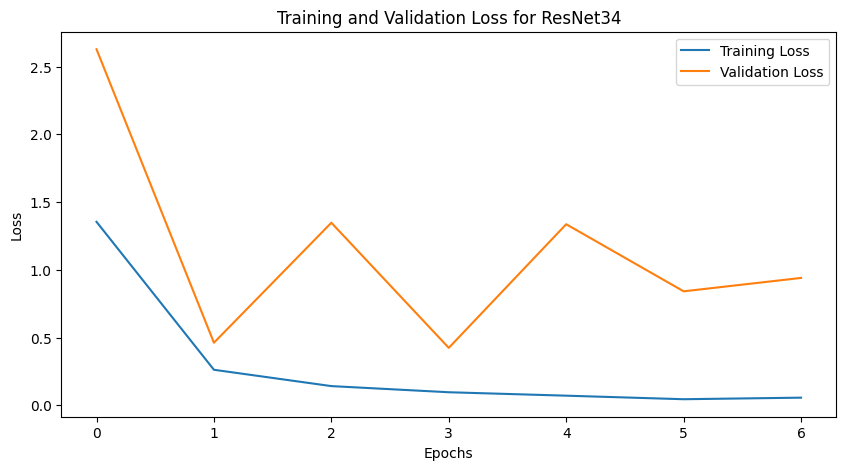

In [ ]:
# Plot Training and Validation Loss

plt.figure(figsize=(10,5))
plt.plot(train_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for ResNet50')
plt.legend()
plt.show()

--------------------------------------------------
FINAL TEST RESULTS
--------------------------------------------------
Test Accuracy: 80.77%

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.79      0.66      0.72       234
   PNEUMONIA       0.81      0.90      0.85       390

    accuracy                           0.81       624
   macro avg       0.80      0.78      0.79       624
weighted avg       0.81      0.81      0.80       624

Confusion Matrix:


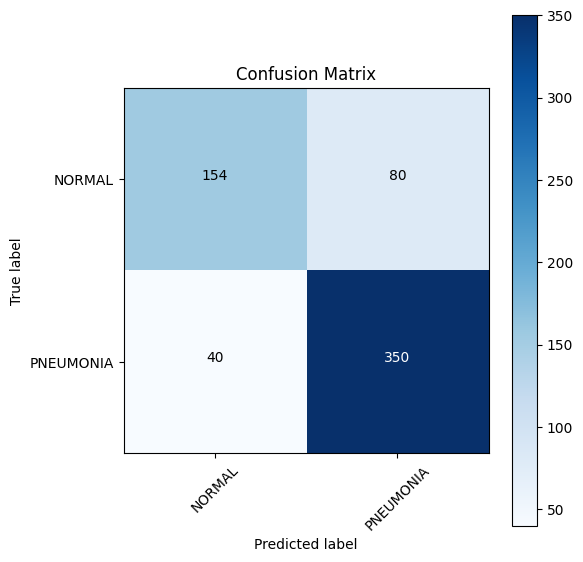


True Negatives (NORMAL correctly predicted): 154
False Positives (NORMAL predicted as PNEUMONIA): 80
False Negatives (PNEUMONIA predicted as NORMAL): 40
True Positives (PNEUMONIA correctly predicted): 350


In [22]:
# Load best model
model_resnet.load_state_dict(torch.load('best_resnet50_model.pth'))
model_resnet.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate metrics
test_acc = 100 * np.sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)

print("-" * 50)
print(f"FINAL TEST RESULTS")
print("-" * 50)
print(f"Test Accuracy: {test_acc:.2f}%\n")

# Classification Report
class_names = ['NORMAL', 'PNEUMONIA']
print("Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=class_names))

# Confusion Matrix
print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (NORMAL correctly predicted): {cm[0][0]}")
print(f"False Positives (NORMAL predicted as PNEUMONIA): {cm[0][1]}")
print(f"False Negatives (PNEUMONIA predicted as NORMAL): {cm[1][0]}")
print(f"True Positives (PNEUMONIA correctly predicted): {cm[1][1]}")